# Top 10 AI Usage in Indonesia by Job Family
Fully standalone — no prior code needed. Runs from scratch.

In [1]:
# !pip install huggingface_hub pandas matplotlib -q

from huggingface_hub import hf_hub_download
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

REPO      = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

def load(path):
    local = hf_hub_download(repo_id=REPO, filename=path, repo_type=REPO_TYPE)
    return pd.read_csv(local)

print('Loading data...')

# --- 1. Task penetration (global baseline) ---
task_penetration = load('labor_market_impacts/task_penetration.csv')
task_penetration['task'] = task_penetration['task'].str.lower().str.strip()

# --- 2. O*NET task statements (task → occupation mapping) ---
onet_tasks = load('release_2025_02_10/onet_task_statements.csv')
onet_tasks['task_clean'] = onet_tasks['Task'].str.lower().str.strip()

# --- 3. Wages (occupation → Job Family mapping) ---
wages = load('release_2025_02_10/wage_data.csv')
wages['occ_code'] = wages['SOCcode'].str[:7]
wages_deduped = (wages
    .sort_values('JobForecast', ascending=False)
    .drop_duplicates(subset='occ_code', keep='first')
[['occ_code', 'JobFamily']])

# --- 4. Geographic AEI data (country-level task usage) ---
aei = load('release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv')

# Keep only country-level onet_task penetration rows
onet_geo = aei[
    (aei['geography'] == 'country') &
    (aei['facet']     == 'onet_task') &
    (aei['variable']  == 'onet_task_pct')
][['geo_id', 'cluster_name', 'value']].rename(columns={
    'cluster_name': 'task',
    'value':        'country_pct'
})
onet_geo['task'] = onet_geo['task'].str.lower().str.strip()

print(f'  task_penetration : {task_penetration.shape}')
print(f'  onet_tasks       : {onet_tasks.shape}')
print(f'  wages_deduped    : {wages_deduped.shape}')
print(f'  onet_geo         : {onet_geo.shape}')
print(f'  countries        : {onet_geo["geo_id"].nunique()}')
print('Done.')

Loading data...


  task_penetration : (17998, 2)
  onet_tasks       : (19530, 9)
  wages_deduped    : (821, 2)
  onet_geo         : (7485, 3)
  countries        : 118
Done.


In [2]:
# --- Join pipeline ---
# onet_geo (country × task × country_pct)
# + task_penetration (task × global penetration)
# + onet_tasks (task → occ_code)
# + wages_deduped (occ_code → JobFamily)

df = (
    onet_geo
    # global baseline
    .merge(task_penetration, on='task', how='left')
    # occupation code
    .merge(
        onet_tasks[['task_clean', 'O*NET-SOC Code']].drop_duplicates(),
        left_on='task', right_on='task_clean', how='left'
    )
    .assign(occ_code=lambda x: x['O*NET-SOC Code'].str[:7])
    # Job Family
    .merge(wages_deduped, on='occ_code', how='left')
    .dropna(subset=['JobFamily', 'penetration'])
)

print(f'Joined rows: {len(df)}')
print(f'Job Families found: {df["JobFamily"].nunique()}')
display(df[['geo_id','task','country_pct','penetration','JobFamily']].head(4))

Joined rows: 9489
Job Families found: 22


,geo_id,task,country_pct,penetration,JobFamily
1,AE,analyze information obtained from management t...,0.318878,0.8842,Computer and Mathematical
2,AE,analyze operations to evaluate performance of ...,0.531463,0.8310,Management
3,AE,analyze user needs and software requirements t...,0.659014,0.9097,Computer and Mathematical
4,AE,"answer customers' questions about products, pr...",0.531463,0.9817,Sales and Related


In [3]:
# --- Aggregate to country × JobFamily ---
family_gap_all = (
    df
    .groupby(['geo_id', 'JobFamily'])
    .agg(
        mean_country_penetration = ('country_pct',  'mean'),
        mean_global_penetration  = ('penetration',  'mean'),
        n_tasks                  = ('task',         'count')
    )
    .reset_index()
)
family_gap_all['gap'] = (
    family_gap_all['mean_global_penetration'] -
    family_gap_all['mean_country_penetration']
)

print('family_gap_all shape:', family_gap_all.shape)
display(family_gap_all.head(3))

family_gap_all shape: (735, 6)


,geo_id,JobFamily,mean_country_penetration,mean_global_penetration,n_tasks,gap
0,AE,"Arts, Design, Entertainment, Sports, and Media",0.719246,0.8375,6,0.118254
1,AE,Business and Financial Operations,0.340136,0.7393,1,0.399164
2,AE,Community and Social Service,0.382653,0.0000,1,-0.382653


In [4]:
# --- Top 10 Indonesia by AI usage ---
top10 = (
    family_gap_all[family_gap_all['geo_id'] == 'ID']
    .sort_values('mean_country_penetration', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 Job Families by AI Usage in Indonesia:')
display(top10[['JobFamily','mean_country_penetration','mean_global_penetration','gap','n_tasks']])

Top 10 Job Families by AI Usage in Indonesia:


,JobFamily,mean_country_penetration,mean_global_penetration,gap,n_tasks
0,Computer and Mathematical,0.742959,0.905289,0.162330,27
1,"Arts, Design, Entertainment, Sports, and Media",0.393074,0.895067,0.501993,9
2,Office and Administrative Support,0.360682,0.838700,0.478018,9
3,"Education, Training, and Library",0.334985,0.867317,0.532332,215
4,Community and Social Service,0.265259,0.581400,0.316141,3
5,Sales and Related,0.244248,0.954500,0.710252,3
6,"Farming, Fishing, and Forestry",0.212732,0.909500,0.696768,1
7,"Life, Physical, and Social Science",0.169398,0.936800,0.767402,6
8,Personal Care and Service,0.152327,0.570733,0.418406,3
9,Food Preparation and Serving Related,0.149701,0.843300,0.693599,1


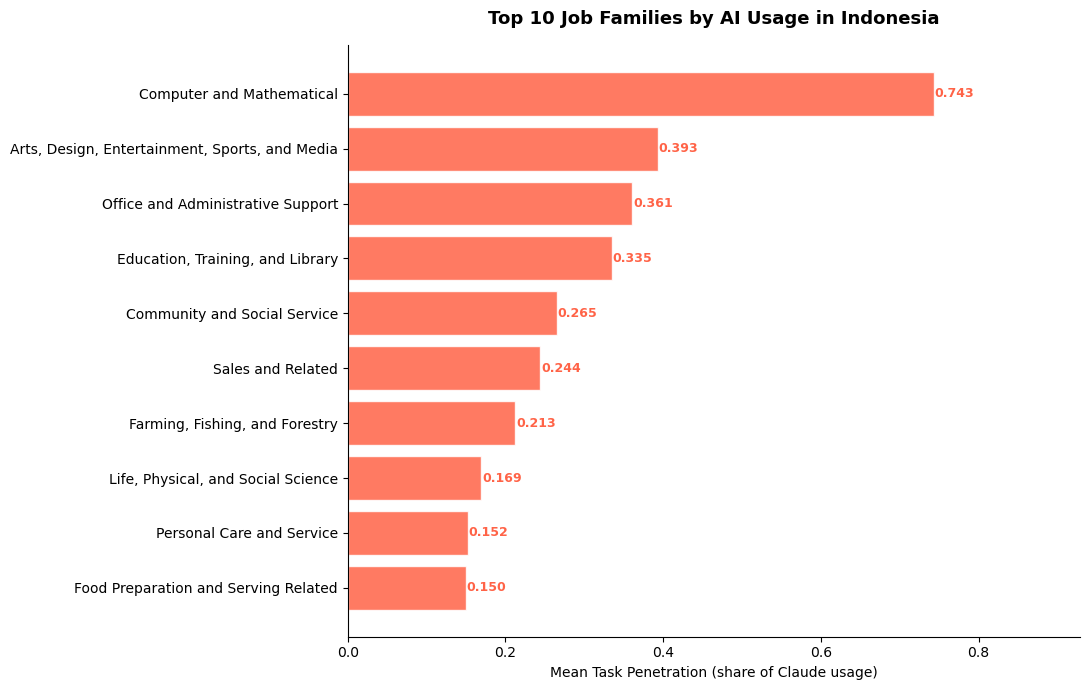

Saved: processed/top10_indonesia_only.png


In [7]:
plot_df = top10.sort_values('mean_country_penetration', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    plot_df['JobFamily'],
    plot_df['mean_country_penetration'],
    color='tomato', alpha=0.85, edgecolor='white'
)

# Value labels
for bar, val in zip(bars, plot_df['mean_country_penetration']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9,
            color='tomato', fontweight='bold')

ax.set_xlabel('Mean Task Penetration (share of Claude usage)', fontsize=10)
ax.set_title('Top 10 Job Families by AI Usage in Indonesia',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, plot_df['mean_country_penetration'].max() * 1.25)


plt.tight_layout()
os.makedirs('processed', exist_ok=True)
plt.savefig('processed/top10_indonesia_only.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: processed/top10_indonesia_only.png')

In [2]:
from huggingface_hub import hf_hub_download
import pandas as pd

REPO      = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

auto_by_task = pd.read_csv(
    hf_hub_download(REPO, 'release_2025_03_27/automation_vs_augmentation_by_task.csv', repo_type=REPO_TYPE)
)
print('columns:', auto_by_task.columns.tolist())
display(auto_by_task.head(5))

columns: ['task_name', 'feedback_loop', 'directive', 'task_iteration', 'validation', 'learning', 'filtered']


,task_name,feedback_loop,directive,task_iteration,validation,learning,filtered
0,accept commissions to create music for special...,0.0,0.000000,0.000000,0.0,0.0,1.000000
1,act as advisers to student organizations.,0.0,0.382979,0.361702,0.0,0.0,0.255319
2,act as an advocate for farmers or farmers' gro...,0.0,0.000000,0.000000,0.0,0.0,1.000000
3,act as an intermediary in negotiations between...,0.0,0.391304,0.434783,0.0,0.0,0.173913
4,act as an intermediary in negotiations between...,0.0,0.391304,0.376812,0.0,0.0,0.231884


Business & Financial Operations — top 15 tasks: 0


,task_name,penetration,automated,augmented


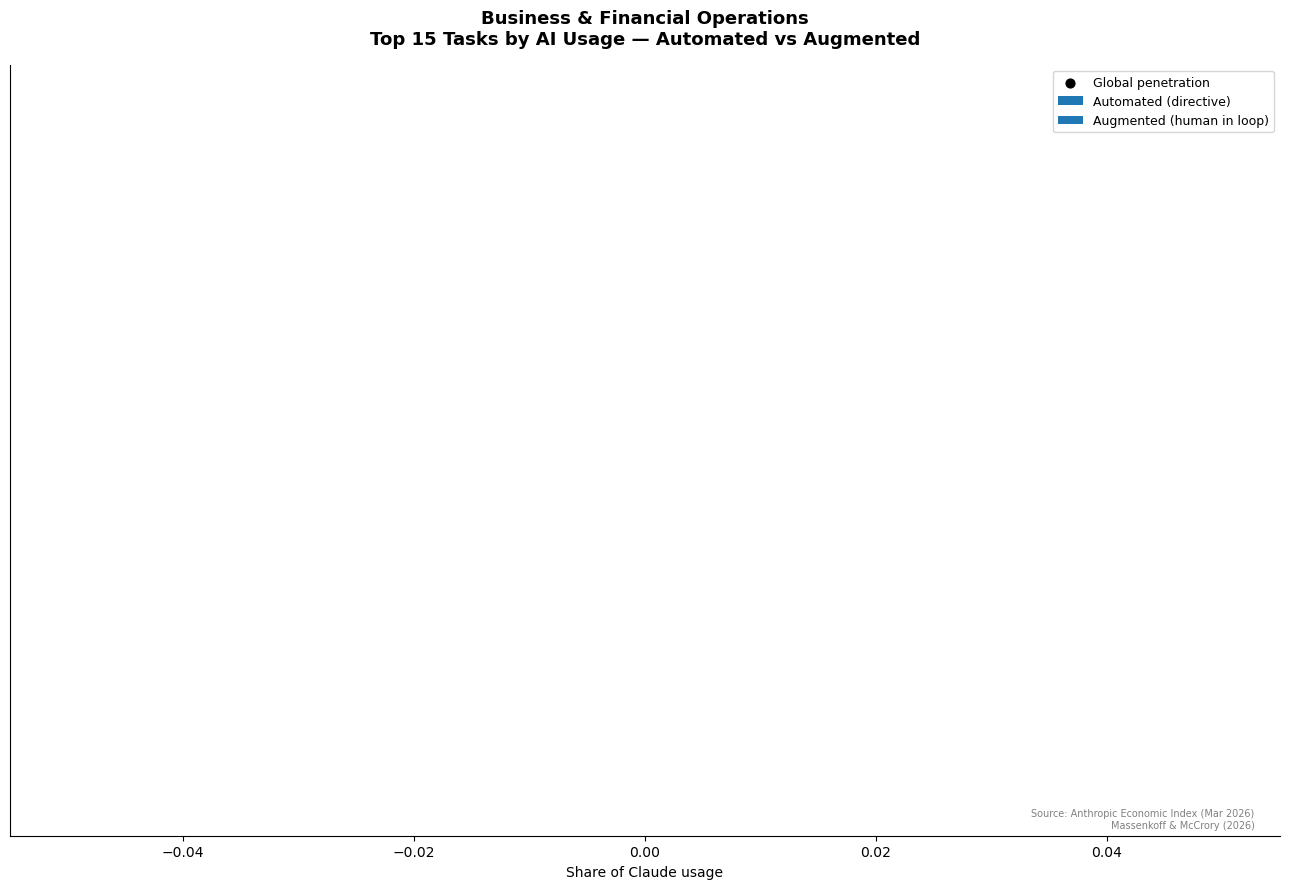

Saved.


In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO      = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

def load(path):
    return pd.read_csv(hf_hub_download(REPO, path, repo_type=REPO_TYPE))

# Load all needed files
auto_by_task     = load('release_2025_03_27/automation_vs_augmentation_by_task.csv')
task_penetration = load('labor_market_impacts/task_penetration.csv')
onet_tasks       = load('release_2025_02_10/onet_task_statements.csv')
wages            = load('release_2025_02_10/wage_data.csv')

# Build occupation → JobFamily mapping
wages['occ_code'] = wages['SOCcode'].str[:7]
wages_deduped = (wages
    .sort_values('JobForecast', ascending=False)
    .drop_duplicates(subset='occ_code', keep='first')
[['occ_code', 'JobFamily']])

# Normalize task text
auto_by_task['task_clean']   = auto_by_task['task_name'].str.lower().str.strip()
task_penetration['task_clean'] = task_penetration['task'].str.lower().str.strip()
onet_tasks['task_clean']     = onet_tasks['Task'].str.lower().str.strip()

# Join pipeline: auto_by_task → penetration → occ_code → JobFamily
df = (
    auto_by_task
    .merge(task_penetration.rename(columns={'task':'task_name'})[['task_name','penetration']], 
           on='task_name', how='left')
    .merge(onet_tasks[['task_clean','O*NET-SOC Code']].drop_duplicates(),
           on='task_clean', how='left')
    .assign(occ_code=lambda x: x['O*NET-SOC Code'].str[:7])
    .merge(wages_deduped, on='occ_code', how='left')
    .dropna(subset=['JobFamily', 'penetration'])
)

# Label automated vs augmented
# directive = automated; feedback_loop + task_iteration + validation + learning = augmented
df['automated']  = df['directive']
df['augmented']  = df[['feedback_loop','task_iteration','validation','learning']].sum(axis=1)

# Filter to Business & Financial Operations
biz = (
    df[df['JobFamily'] == 'Business and Financial Operations']
    .sort_values('penetration', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print(f'Business & Financial Operations — top 15 tasks: {len(biz)}')
display(biz[['task_name','penetration','automated','augmented']].round(3))

# --- Plot ---
plot_df = biz.sort_values('penetration', ascending=True).reset_index(drop=True)

# Shorten task names for display
plot_df['label'] = plot_df['task_name'].str.slice(0, 55) + '...'

fig, ax = plt.subplots(figsize=(13, 9))

y = np.arange(len(plot_df))
w = 0.35

ax.barh(y + w/2, plot_df['automated'], height=w,
        color='tomato', alpha=0.88, label='Automated (directive)')
ax.barh(y - w/2, plot_df['augmented'], height=w,
        color='steelblue', alpha=0.88, label='Augmented (human in loop)')

# Penetration dots
ax.scatter(plot_df['penetration'], y, color='black', zorder=5,
           s=40, label='Global penetration')

ax.set_yticks(y)
ax.set_yticklabels(plot_df['label'], fontsize=8)
ax.set_xlabel('Share of Claude usage', fontsize=10)
ax.set_title('Business & Financial Operations\nTop 15 Tasks by AI Usage — Automated vs Augmented',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.98, 0.01,
        'Source: Anthropic Economic Index (Mar 2026)\nMassenkoff & McCrory (2026)',
        transform=ax.transAxes, fontsize=7, ha='right', color='gray')

plt.tight_layout()
plt.savefig('processed/biz_finance_auto_vs_aug.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

In [4]:
print(df['JobFamily'].unique())

[]


In [5]:
# Check each join step individually
print('=== auto_by_task ===')
print(auto_by_task['task_clean'].head(3).tolist())

print('\n=== task_penetration ===')
print(task_penetration['task_clean'].head(3).tolist())

print('\n=== onet_tasks ===')
print(onet_tasks['task_clean'].head(3).tolist())

# Step 1: auto_by_task + penetration
step1 = auto_by_task.merge(
    task_penetration[['task_clean', 'penetration']],
    on='task_clean', how='left'
)
print('\n=== Step 1: auto + penetration ===')
print('rows:', len(step1), '| penetration matched:', step1['penetration'].notna().sum())

# Step 2: + occ_code
step2 = step1.merge(
    onet_tasks[['task_clean', 'O*NET-SOC Code']].drop_duplicates(),
    on='task_clean', how='left'
)
print('\n=== Step 2: + occ_code ===')
print('rows:', len(step2), '| occ matched:', step2['O*NET-SOC Code'].notna().sum())

# Step 3: + JobFamily
step2['occ_code'] = step2['O*NET-SOC Code'].str[:7]
step3 = step2.merge(wages_deduped, on='occ_code', how='left')
print('\n=== Step 3: + JobFamily ===')
print('rows:', len(step3), '| JobFamily matched:', step3['JobFamily'].notna().sum())
print('sample JobFamilies:', step3['JobFamily'].dropna().unique()[:5].tolist())

=== auto_by_task ===
['accept commissions to create music for special occasions.', 'act as advisers to student organizations.', "act as an advocate for farmers or farmers' groups."]

=== task_penetration ===
['accept and check containers of mail from large volume mailers, couriers, and contractors.', 'accept and check containers of mail or parcels from large volume mailers, couriers, and contractors.', 'accept credit applications and verify credit references to provide check-cashing authorization or to establish house credit accounts.']

=== onet_tasks ===
["direct or coordinate an organization's financial or budget activities to fund operations, maximize investments, or increase efficiency.", 'appoint department heads or managers and assign or delegate responsibilities to them.', 'analyze operations to evaluate performance of a company or its staff in meeting objectives or to determine areas of potential cost reduction, program improvement, or policy change.']

=== Step 1: auto + pene

In [6]:
print(sorted(df['JobFamily'].dropna().unique()))

[]
